# Natural Language Processing (NLP) — Full Workshop Notebook

A single, end-to-end notebook for teaching an NLP workshop, covering:

1. Introduction & Phases of NLP
2. NLP Libraries (NLTK, spaCy, TextBlob, Gensim, Hugging Face Transformers)
3. Text Preprocessing (Tokenization, Stopwords, Punctuation, Stemming, Lemmatization, Normalization, POS Tagging, Parsing)
4. Text Representation (One-Hot, Bag of Words, TF-IDF, N-Grams, LSA, LDA)
5. Text Embeddings (Word2Vec, GloVe, fastText, Doc2Vec, BERT embeddings)
6. Model Training — Traditional ML (Naive Bayes, Logistic Regression, SVM, Random Forest)
7. Deep Learning for NLP (ANN, RNN, LSTM, GRU)
8. Sequence-to-Sequence & Transformer Architecture
9. Pretrained Language Models (BERT, GPT-2, T5) via Hugging Face
10. Core NLP Tasks (Classification, NER, Sentiment Analysis, Machine Translation, Summarization, Text Generation, Question Answering)
11. Real-world Applications
12. Wrap-up & Practice Exercises

> **Data note:** Every section uses either a **synthetic dataset generated in code** (so it works with zero downloads and is easy to explain) or a **small, well-known dataset pulled from a library** (e.g., `sklearn.datasets`, `nltk` corpora, `gensim` corpora). This keeps the workshop self-contained and reproducible.

> **Environment note:** This notebook is designed for **Google Colab** or a local environment with internet access, since some sections (spaCy models, Hugging Face models, pretrained word vectors) need one-time downloads. Each section's first cell installs/downloads what it needs — run cells top to bottom.


## 0. Setup

Run this once at the start of the workshop. It installs every library used below.
If you're on Google Colab, most of these (numpy, pandas, sklearn, matplotlib) are pre-installed already.


In [1]:
# Core installs (safe to re-run)
!pip install -q nltk spacy textblob gensim transformers torch scikit-learn matplotlib seaborn wordcloud sumy sentencepiece sacremoses
!python -m spacy download en_core_web_sm -q



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


c:\Users\siddh\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

pd.set_option("display.max_colwidth", 120)
print("Setup complete.")


Setup complete.


## 1. Introduction to NLP & Phases of NLP

**Natural Language Processing (NLP)** is the branch of AI concerned with letting machines read, understand,
interpret and generate human language (text or speech).

### The 5 classic phases of an NLP pipeline

| Phase | What happens | Example |
|---|---|---|
| **1. Lexical / Morphological Analysis** | Break text into tokens, identify word structure | `"running"` → `run` + `-ing` |
| **2. Syntactic Analysis (Parsing)** | Check grammar, build a parse tree | Subject–Verb–Object structure |
| **3. Semantic Analysis** | Extract literal meaning of words/sentences | `"bank"` (river) vs `"bank"` (money) |
| **4. Discourse Integration** | Understand meaning in context of surrounding sentences | Pronoun resolution across sentences |
| **5. Pragmatic Analysis** | Understand intended meaning (real-world knowledge, tone) | Sarcasm, "Can you pass the salt?" = request, not a yes/no question |

We'll touch each of these phases as we go through preprocessing, representation, and modeling below.


In [3]:
# A toy sentence to keep referring back to throughout the workshop
demo_sentence = "The quick brown foxes are jumping over the lazy dogs near New York City!"
print(demo_sentence)


The quick brown foxes are jumping over the lazy dogs near New York City!


## 2. NLP Libraries

A quick tour of the major Python NLP libraries and what each is best known for.

| Library | Best known for |
|---|---|
| **NLTK** | Classic, teaching-friendly toolkit: tokenizing, stemming, POS tagging, corpora |
| **spaCy** | Fast, production-grade pipelines: tokenization, POS, NER, dependency parsing |
| **TextBlob** | Simple API on top of NLTK, great for quick sentiment/polarity |
| **Gensim** | Topic modeling & word vectors (Word2Vec, LDA, Doc2Vec) at scale |
| **Hugging Face Transformers** | Pretrained deep learning models (BERT, GPT, T5, ...) via `pipeline()` |


In [4]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('maxent_ne_chunker', quiet=True)
nltk.download('maxent_ne_chunker_tab', quiet=True)
nltk.download('words', quiet=True)
nltk.download('vader_lexicon', quiet=True)

from nltk.tokenize import word_tokenize
print("NLTK tokens:", word_tokenize(demo_sentence))


NLTK tokens: ['The', 'quick', 'brown', 'foxes', 'are', 'jumping', 'over', 'the', 'lazy', 'dogs', 'near', 'New', 'York', 'City', '!']


In [5]:
import spacy
nlp = spacy.load("en_core_web_sm")

doc = nlp(demo_sentence)
print("spaCy tokens:", [tok.text for tok in doc])


spaCy tokens: ['The', 'quick', 'brown', 'foxes', 'are', 'jumping', 'over', 'the', 'lazy', 'dogs', 'near', 'New', 'York', 'City', '!']


In [6]:
from textblob import TextBlob

blob = TextBlob(demo_sentence)
print("TextBlob words:", blob.words)
print("TextBlob sentiment:", blob.sentiment)


TextBlob words: ['The', 'quick', 'brown', 'foxes', 'are', 'jumping', 'over', 'the', 'lazy', 'dogs', 'near', 'New', 'York', 'City']
TextBlob sentiment: Sentiment(polarity=0.08844696969696969, subjectivity=0.5886363636363636)


In [7]:
import gensim
print("Gensim version:", gensim.__version__)


Gensim version: 4.4.0


In [8]:
from transformers import pipeline
print("Transformers ready. We'll build pipelines (sentiment, NER, translation, summarization, "
      "generation, QA) in Section 10.")


Transformers ready. We'll build pipelines (sentiment, NER, translation, summarization, generation, QA) in Section 10.


## 3. Text Preprocessing Techniques

Raw text is messy. Before any modeling we typically apply some subset of:
Tokenization → Stopword Removal → Punctuation Removal → Stemming/Lemmatization → Normalization → POS Tagging → Parsing.

### Synthetic dataset for this section
A handful of short, messy "customer review" style sentences — deliberately including punctuation,
mixed case, and stopwords so every technique below has something to do.


In [9]:
raw_reviews = [
    "The Delivery was FAST!!! I loved the packaging, and it arrived earlier than expected :)",
    "Terrible experience... the product broke after just 2 days. Very disappointed.",
    "It's okay, not the best but not the worst either. Works as described.",
    "Absolutely amazing quality!! Will definitely buy again from this store.",
    "The customer support team was unhelpful and rude when I called them.",
    "Best purchase I've made this year - runs smoothly and looks great on my desk.",
    "Meh. The battery life is shorter than advertised, and it overheats sometimes.",
    "Five stars!!! Fast shipping, great price, and excellent build quality.",
]
for r in raw_reviews:
    print("-", r)


- The Delivery was FAST!!! I loved the packaging, and it arrived earlier than expected :)
- Terrible experience... the product broke after just 2 days. Very disappointed.
- It's okay, not the best but not the worst either. Works as described.
- Absolutely amazing quality!! Will definitely buy again from this store.
- The customer support team was unhelpful and rude when I called them.
- Best purchase I've made this year - runs smoothly and looks great on my desk.
- Meh. The battery life is shorter than advertised, and it overheats sometimes.
- Five stars!!! Fast shipping, great price, and excellent build quality.


### 3.1 Tokenization
Splitting text into smaller units — words or sentences.


In [10]:
from nltk.tokenize import word_tokenize, sent_tokenize

sample = raw_reviews[0]
print("Sentence tokens:", sent_tokenize(sample))
print("Word tokens:", word_tokenize(sample))


Sentence tokens: ['The Delivery was FAST!!!', 'I loved the packaging, and it arrived earlier than expected :)']
Word tokens: ['The', 'Delivery', 'was', 'FAST', '!', '!', '!', 'I', 'loved', 'the', 'packaging', ',', 'and', 'it', 'arrived', 'earlier', 'than', 'expected', ':', ')']


### 3.2 Punctuation Removal

In [11]:
import string

def remove_punctuation(text):
    return text.translate(str.maketrans("", "", string.punctuation))

cleaned_punct = [remove_punctuation(r) for r in raw_reviews]
pd.DataFrame({"original": raw_reviews, "no_punctuation": cleaned_punct})


,original,no_punctuation
0,"The Delivery was FAST!!! I loved the packaging, and it arrived earlier than expected :)",The Delivery was FAST I loved the packaging and it arrived earlier than expected
1,Terrible experience... the product broke after just 2 days. Very disappointed.,Terrible experience the product broke after just 2 days Very disappointed
2,"It's okay, not the best but not the worst either. Works as described.",Its okay not the best but not the worst either Works as described
3,Absolutely amazing quality!! Will definitely buy again from this store.,Absolutely amazing quality Will definitely buy again from this store
4,The customer support team was unhelpful and rude when I called them.,The customer support team was unhelpful and rude when I called them
5,Best purchase I've made this year - runs smoothly and looks great on my desk.,Best purchase Ive made this year runs smoothly and looks great on my desk
6,"Meh. The battery life is shorter than advertised, and it overheats sometimes.",Meh The battery life is shorter than advertised and it overheats sometimes
7,"Five stars!!! Fast shipping, great price, and excellent build quality.",Five stars Fast shipping great price and excellent build quality


### 3.3 Stopword Removal
Stopwords (`the`, `is`, `and`, ...) carry little topical meaning and are often removed for
bag-of-words style models (though modern transformer models usually keep them).


In [12]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    tokens = word_tokenize(text.lower())
    return [t for t in tokens if t.isalpha() and t not in stop_words]

tokens_no_stop = [remove_stopwords(r) for r in raw_reviews]
for original, toks in zip(raw_reviews[:3], tokens_no_stop[:3]):
    print(original)
    print(" ->", toks, "\n")


The Delivery was FAST!!! I loved the packaging, and it arrived earlier than expected :)
 -> ['delivery', 'fast', 'loved', 'packaging', 'arrived', 'earlier', 'expected'] 

Terrible experience... the product broke after just 2 days. Very disappointed.
 -> ['terrible', 'experience', 'product', 'broke', 'days', 'disappointed'] 

It's okay, not the best but not the worst either. Works as described.
 -> ['okay', 'best', 'worst', 'either', 'works', 'described'] 



### 3.4 Stemming
Chops word endings using rules — fast, but can produce non-words (`"studies"` → `"studi"`).


In [13]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()
words = ["running", "studies", "flies", "happily", "better", "connection"]
for w in words:
    print(f"{w:12s} -> {stemmer.stem(w)}")


running      -> run
studies      -> studi
flies        -> fli
happily      -> happili
better       -> better
connection   -> connect


### 3.5 Lemmatization
Uses vocabulary + morphological analysis to return the dictionary (base) form — slower, but linguistically correct.


In [14]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
words = ["running", "studies", "flies", "happily", "better", "connection"]
print(f"{'word':12s} {'stem':12s} {'lemma (verb)':14s} {'lemma (noun)'}")
for w in words:
    print(f"{w:12s} {stemmer.stem(w):12s} {lemmatizer.lemmatize(w, pos='v'):14s} {lemmatizer.lemmatize(w, pos='n')}")


word         stem         lemma (verb)   lemma (noun)
running      run          run            running
studies      studi        study          study
flies        fli          fly            fly
happily      happili      happily        happily
better       better       better         better
connection   connect      connection     connection


### 3.6 Text Normalization
Lower-casing, expanding contractions, fixing repeated characters, removing extra whitespace, etc.


In [15]:
import re

contractions = {
    "don't": "do not", "can't": "cannot", "it's": "it is", "i've": "i have",
    "won't": "will not", "isn't": "is not", "didn't": "did not",
}

def normalize(text):
    text = text.lower()
    for c, full in contractions.items():
        text = text.replace(c, full)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)      # "sooooo" -> "soo"
    text = re.sub(r"[^a-z0-9\s]", " ", text)          # strip punctuation/emoji
    text = re.sub(r"\s+", " ", text).strip()          # collapse whitespace
    return text

messy = "I don't knowwww why it's soooo slowww!!! :((("
print("before:", messy)
print("after :", normalize(messy))


before: I don't knowwww why it's soooo slowww!!! :(((
after : i do not knoww why it is soo sloww


### 3.7 Parts-of-Speech (POS) Tagging
Labels each token with its grammatical role (noun, verb, adjective, ...).


In [16]:
from nltk import pos_tag

tokens = word_tokenize(demo_sentence)
tags = pos_tag(tokens)
pd.DataFrame(tags, columns=["token", "POS_tag"])


,token,POS_tag
0,The,DT
1,quick,JJ
2,brown,NN
3,foxes,NNS
4,are,VBP
5,jumping,VBG
6,over,IN
7,the,DT
8,lazy,JJ
9,dogs,NNS


In [17]:
# The same thing in spaCy, with human-readable explanations
doc = nlp(demo_sentence)
pd.DataFrame(
    [(tok.text, tok.pos_, spacy.explain(tok.pos_)) for tok in doc],
    columns=["token", "POS_tag", "meaning"]
)


,token,POS_tag,meaning
0,The,DET,determiner
1,quick,ADJ,adjective
2,brown,ADJ,adjective
3,foxes,NOUN,noun
4,are,AUX,auxiliary
5,jumping,VERB,verb
6,over,ADP,adposition
7,the,DET,determiner
8,lazy,ADJ,adjective
9,dogs,NOUN,noun


### 3.8 Parsing (Dependency Parsing)
Builds a tree of grammatical relationships between words — who is doing what to whom.


In [18]:
for tok in doc:
    print(f"{tok.text:12s} --{tok.dep_:10s}--> {tok.head.text}")


The          --det       --> foxes
quick        --amod      --> foxes
brown        --amod      --> foxes
foxes        --nsubj     --> jumping
are          --aux       --> jumping
jumping      --ROOT      --> jumping
over         --prep      --> jumping
the          --det       --> dogs
lazy         --amod      --> dogs
dogs         --pobj      --> over
near         --prep      --> dogs
New          --compound  --> York
York         --compound  --> City
City         --pobj      --> near
!            --punct     --> jumping


In [19]:
from spacy import displacy

# Renders an inline dependency tree (works in Jupyter/Colab)
displacy.render(nlp("The dog chased the cat."), style="dep", jupyter=True)


## 4. Text Representation Techniques

Machine learning models need numbers, not words. This section converts text → vectors.

### Synthetic dataset for this section
A small multi-topic corpus generated from templates across 4 topics: **sports, technology, food, finance**.
Because we control the generation, we know the ground-truth topic of every document — perfect for
demonstrating BoW/TF-IDF/LSA/LDA and (later) topic-aware classifiers.


In [11]:
topic_vocab = {
    "sports": ["match", "goal", "team", "player", "coach", "stadium", "score", "tournament", "referee", "championship"],
    "technology": ["software", "algorithm", "processor", "network", "server", "code", "device", "startup", "cloud", "data"],
    "food": ["recipe", "flavor", "restaurant", "chef", "ingredient", "spice", "dessert", "kitchen", "dish", "cuisine"],
    "finance": ["stock", "market", "investor", "budget", "interest", "revenue", "portfolio", "bank", "currency", "profit"],
}

templates = [
    "The {a} was impressive because the {b} really stood out this season.",
    "Experts discussed how the {a} could change the future of {b} for everyone.",
    "Our team analyzed the {a} and found the {b} more important than expected.",
    "Yesterday's report on {a} highlighted a surprising link to {b}.",
    "Many people are talking about the {a} and how it affects {b} nationwide.",
]

def generate_document(topic, rng):
    vocab = topic_vocab[topic]
    template = rng.choice(templates)
    a, b = rng.sample(vocab, 2)
    return template.format(a=a, b=b)

rng = random.Random(42)
documents, doc_topics = [], []
for topic in topic_vocab:
    for _ in range(15):
        documents.append(generate_document(topic, rng))
        doc_topics.append(topic)

corpus_df = pd.DataFrame({"text": documents, "topic": doc_topics}).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Generated {len(corpus_df)} synthetic documents across {corpus_df['topic'].nunique()} topics.")
corpus_df.head(8)


Generated 60 synthetic documents across 4 topics.


,text,topic
0,The match was impressive because the coach really stood out this season.,sports
1,Experts discussed how the referee could change the future of match for everyone.,sports
2,Yesterday's report on flavor highlighted a surprising link to recipe.,food
3,Many people are talking about the investor and how it affects currency nationwide.,finance
4,Our team analyzed the championship and found the coach more important than expected.,sports
5,Many people are talking about the investor and how it affects profit nationwide.,finance
6,Many people are talking about the ingredient and how it affects dessert nationwide.,food
7,Our team analyzed the investor and found the currency more important than expected.,finance


### 4.1 One-Hot Encoding
Each unique word becomes a vector with a single `1` and the rest `0`s — simple but huge and sparse,
and it captures no relationship between words.


In [21]:
from sklearn.preprocessing import OneHotEncoder

sample_words = np.array(["match", "goal", "team", "match", "player"]).reshape(-1, 1)
encoder = OneHotEncoder(sparse_output=False)
one_hot = encoder.fit_transform(sample_words)

pd.DataFrame(one_hot, columns=encoder.categories_[0], index=sample_words.flatten())


,goal,match,player,team
match,0.0,1.0,0.0,0.0
goal,1.0,0.0,0.0,0.0
team,0.0,0.0,0.0,1.0
match,0.0,1.0,0.0,0.0
player,0.0,0.0,1.0,0.0


### 4.2 Bag of Words (BoW)
Represents each document as word counts, ignoring order/grammar.


In [22]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(stop_words="english")
bow_matrix = bow_vectorizer.fit_transform(corpus_df["text"])

print("BoW matrix shape:", bow_matrix.shape)
pd.DataFrame(bow_matrix[:5].toarray(), columns=bow_vectorizer.get_feature_names_out()).loc[:, (bow_matrix[:5].toarray() != 0).any(axis=0)]


BoW matrix shape: (60, 58)


,affects,analyzed,championship,change,coach,currency,discussed,expected,experts,flavor,...,really,recipe,referee,report,season,stood,surprising,talking,team,yesterday
0,0,0,0,0,1,0,0,0,0,0,...,1,0,0,0,1,1,0,0,0,0
1,0,0,0,1,0,0,1,0,1,0,...,0,0,1,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,1,...,0,1,0,1,0,0,1,0,0,1
3,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,0,1,1,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0


### 4.3 TF-IDF (Term Frequency–Inverse Document Frequency)
Weighs words by how important they are to a document *relative to the whole corpus* —
common words across all documents get down-weighted.


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus_df["text"])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

# Top TF-IDF terms for the first document
first_doc_scores = pd.Series(tfidf_matrix[0].toarray().flatten(), index=tfidf_vectorizer.get_feature_names_out())
print("Document:", corpus_df['text'][0])
first_doc_scores.sort_values(ascending=False).head(5)


TF-IDF matrix shape: (60, 58)
Document: The match was impressive because the coach really stood out this season.


coach     0.537581
match     0.505374
season    0.337492
stood     0.337492
really    0.337492
dtype: float64

### 4.4 N-Gram Language Modeling
Instead of single words ("unigrams"), we can use pairs (bigrams) or triples (trigrams) of
consecutive words to capture some local word order.


In [24]:
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words="english")
bigram_matrix = bigram_vectorizer.fit_transform(corpus_df["text"])

bigram_counts = pd.Series(np.asarray(bigram_matrix.sum(axis=0)).flatten(),
                           index=bigram_vectorizer.get_feature_names_out())
bigram_counts.sort_values(ascending=False).head(10)


really stood              15
stood season              15
people talking            14
team analyzed             12
highlighted surprising    12
yesterday report          12
important expected        12
surprising link           12
change future              7
experts discussed          7
dtype: int64

### 4.5 Latent Semantic Analysis (LSA)
Applies **Truncated SVD** (dimensionality reduction) on the TF-IDF matrix to uncover latent
"topics" as combinations of correlated words.


In [13]:
from sklearn.decomposition import TruncatedSVD

lsa = TruncatedSVD(n_components=4, random_state=42)
lsa_matrix = lsa.fit_transform(tfidf_matrix)

terms = tfidf_vectorizer.get_feature_names_out()
for i, component in enumerate(lsa.components_):
    top_terms = [terms[idx] for idx in component.argsort()[-8:][::-1]]
    print(f"LSA Topic {i}: {top_terms}")


LSA Topic 0: ['stood', 'season', 'really', 'impressive', 'talking', 'people', 'nationwide', 'affects']
LSA Topic 1: ['stood', 'season', 'really', 'impressive', 'market', 'goal', 'algorithm', 'software']
LSA Topic 2: ['yesterday', 'surprising', 'report', 'link', 'highlighted', 'team', 'analyzed', 'important']
LSA Topic 3: ['team', 'analyzed', 'expected', 'important', 'portfolio', 'championship', 'budget', 'server']


### 4.6 Latent Dirichlet Allocation (LDA)
A probabilistic topic model: assumes every document is a mixture of topics, and every topic is
a distribution over words. Let's fit LDA on our BoW matrix and see if it recovers our 4 synthetic topics.


In [26]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=4, random_state=42, max_iter=50)
lda_topic_dist = lda.fit_transform(bow_matrix)

bow_terms = bow_vectorizer.get_feature_names_out()
for i, component in enumerate(lda.components_):
    top_terms = [bow_terms[idx] for idx in component.argsort()[-8:][::-1]]
    print(f"LDA Topic {i}: {top_terms}")


LDA Topic 0: ['stood', 'season', 'really', 'impressive', 'network', 'referee', 'market', 'goal']
LDA Topic 1: ['talking', 'people', 'affects', 'nationwide', 'network', 'investor', 'code', 'dessert']
LDA Topic 2: ['future', 'experts', 'discussed', 'change', 'dish', 'processor', 'score', 'match']
LDA Topic 3: ['team', 'yesterday', 'surprising', 'report', 'highlighted', 'link', 'expected', 'important']


In [28]:
# How well does the dominant LDA topic line up with our TRUE synthetic topic label?
corpus_df["lda_topic"] = lda_topic_dist.argmax(axis=1)
pd.crosstab(corpus_df["topic"], corpus_df["lda_topic"])


lda_topic,0,1,2,3
topic,,,,
finance,3,4,1,7
food,2,3,3,7
sports,4,3,3,5
technology,6,4,0,5


## 5. Text Embedding Techniques

Embeddings map words/documents to **dense** vectors (typically 50–768 dimensions) that capture
semantic meaning — words used in similar contexts end up close together in vector space.

We'll train **Word2Vec** and **Doc2Vec** ourselves on our synthetic corpus (so the workshop doesn't
depend on a multi-GB download), then show how to load **GloVe**/**fastText** pretrained vectors and
how to get contextual **BERT** embeddings from Hugging Face.


### 5.1 Word2Vec (trained on our own corpus)

In [30]:
from gensim.models import Word2Vec

tokenized_corpus = [word_tokenize(doc.lower()) for doc in corpus_df["text"]]

w2v_model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=50,   # embedding dimension
    window=4,          # context window
    min_count=1,
    workers=2,
    sg=1,              # skip-gram (use sg=0 for CBOW)
    epochs=200,
    seed=42,
)

print("Vocabulary size:", len(w2v_model.wv))
print("Vector for 'match':", w2v_model.wv["match"][:8], "...")
print("\nWords most similar to 'market':")
print(w2v_model.wv.most_similar("market", topn=5))


Vocabulary size: 83
Vector for 'match': [ 0.08799541 -0.02233653 -0.07579933  0.01713247  0.33342755  0.5679481
 -0.35872012 -0.08519265] ...

Words most similar to 'market':
[('bank', 0.9629344940185547), ('tournament', 0.9494795203208923), ('cuisine', 0.9320484399795532), ('this', 0.8123832941055298), ('stood', 0.8123694062232971)]


### 5.2 GloVe (pretrained, loaded from a library)
GloVe vectors are pretrained on huge corpora (Wikipedia, Common Crawl). We load a small pretrained
set via `gensim.downloader` (one-time download).


In [31]:
import gensim.downloader as gensim_api

# 'glove-wiki-gigaword-50' is one of the smallest pretrained GloVe sets (~66 MB)
glove_vectors = gensim_api.load("glove-wiki-gigaword-50")

print(glove_vectors.most_similar("king", topn=5))
print("\nAnalogy  king - man + woman  ≈", glove_vectors.most_similar(positive=["king", "woman"], negative=["man"], topn=1))


[==================================================] 100.0% 66.0/66.0MB downloaded
[('prince', 0.8236179351806641), ('queen', 0.7839043140411377), ('ii', 0.7746230363845825), ('emperor', 0.7736247777938843), ('son', 0.766719400882721)]

Analogy  king - man + woman  ≈ [('queen', 0.8523604273796082)]


### 5.3 fastText
fastText (from Facebook AI) learns embeddings for **character n-grams**, so it can represent
out-of-vocabulary and misspelled words far better than Word2Vec/GloVe.


In [32]:
from gensim.models import FastText

ft_model = FastText(sentences=tokenized_corpus, vector_size=50, window=4, min_count=1, epochs=200, seed=42)

# Even a misspelled / unseen word gets a reasonable vector, thanks to subword information
print("Similar to 'stadiums' (never seen exactly, but shares subwords with 'stadium'):")
print(ft_model.wv.most_similar("stadiums", topn=5))


Similar to 'stadiums' (never seen exactly, but shares subwords with 'stadium'):
[('stadium', 0.9996685981750488), ('kitchen', 0.9770098924636841), ('restaurant', 0.9040824770927429), ('startup', 0.9034930467605591), ('player', 0.8747021555900574)]


### 5.4 Doc2Vec
Extends Word2Vec to learn a vector for an **entire document**, not just individual words —
useful for document similarity / clustering.


In [33]:
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

tagged_docs = [TaggedDocument(words=word_tokenize(doc.lower()), tags=[str(i)])
               for i, doc in enumerate(corpus_df["text"])]

doc2vec_model = Doc2Vec(tagged_docs, vector_size=50, window=4, min_count=1, epochs=200, seed=42)

query_vec = doc2vec_model.infer_vector(word_tokenize("the investor checked the stock market report".lower()))
similar_docs = doc2vec_model.dv.most_similar([query_vec], topn=3)
for doc_id, score in similar_docs:
    print(f"score={score:.3f} | {corpus_df['text'][int(doc_id)]}")


score=0.936 | Yesterday's report on stock highlighted a surprising link to market.
score=0.934 | Yesterday's report on recipe highlighted a surprising link to ingredient.
score=0.922 | Yesterday's report on flavor highlighted a surprising link to recipe.


### 5.5 Pretrained Contextual Embeddings: BERT / ELMo
Unlike Word2Vec/GloVe (one fixed vector per word), **BERT** produces a *different* vector for the
same word depending on its sentence context — this is what "contextual embedding" means.


In [34]:
from transformers import AutoTokenizer, AutoModel
import torch

bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert_model = AutoModel.from_pretrained("bert-base-uncased")

sentences = ["I deposited money at the bank.", "We had a picnic on the river bank."]
for sent in sentences:
    inputs = bert_tokenizer(sent, return_tensors="pt")
    with torch.no_grad():
        outputs = bert_model(**inputs)
    tokens = bert_tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    bank_idx = tokens.index("bank")
    bank_vec = outputs.last_hidden_state[0, bank_idx]
    print(f"'{sent}'\n  -> 'bank' vector (first 6 dims): {bank_vec[:6].numpy().round(3)}\n")

print("Notice the two vectors for 'bank' differ — BERT encodes context, GloVe/Word2Vec would give the SAME vector both times.")


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6855.75it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


'I deposited money at the bank.'
  -> 'bank' vector (first 6 dims): [ 0.679 -0.407 -0.069  0.078  0.841  0.146]

'We had a picnic on the river bank.'
  -> 'bank' vector (first 6 dims): [ 0.391 -0.642  0.06  -0.213 -0.263  0.329]

Notice the two vectors for 'bank' differ — BERT encodes context, GloVe/Word2Vec would give the SAME vector both times.


### 5.6 Advanced pretrained variants
- **RoBERTa**: BERT trained longer, on more data, with an improved training recipe → generally stronger.
- **DistilBERT**: a distilled (compressed) version of BERT — ~40% smaller, ~60% faster, ~97% of the performance.

Swapping models is usually a one-line change:


In [35]:
from transformers import AutoTokenizer as AT, AutoModel as AM

for model_name in ["distilbert-base-uncased", "roberta-base"]:
    tok = AT.from_pretrained(model_name)
    print(model_name, "-> vocab size:", tok.vocab_size)


distilbert-base-uncased -> vocab size: 30522
roberta-base -> vocab size: 50265


## 6. Model Training — Traditional Machine Learning

Now that we can vectorize text, let's train real classifiers. This section builds a **synthetic
sentiment-labeled review dataset** (positive / negative) large enough (300 examples) to get a
meaningful train/test split, and compares four classic ML algorithms.


In [36]:
positive_templates = [
    "I absolutely love this {product}, it works {adverb} well!",
    "This {product} exceeded my expectations, truly {adjective}.",
    "Best {product} I've ever bought, {adverb} satisfied.",
    "The {product} is {adjective} and arrived so fast, highly recommend.",
    "What a {adjective} {product}! Worth every penny.",
]
negative_templates = [
    "This {product} is {adjective}, I regret buying it.",
    "Terrible {product}, it stopped working {adverb} quickly.",
    "I'm very disappointed with this {product}, {adjective} quality.",
    "Would not recommend this {product}, it's {adjective}.",
    "The {product} broke {adverb} after I opened the box, {adjective}.",
]
products = ["phone", "laptop", "headphones", "blender", "chair", "backpack", "watch", "camera", "speaker", "monitor"]
pos_adjectives = ["fantastic", "excellent", "wonderful", "amazing", "great"]
neg_adjectives = ["awful", "horrible", "disappointing", "poor", "useless"]
adverbs = ["incredibly", "surprisingly", "remarkably", "really", "very"]

def make_review(templates, adjectives, rng):
    t = rng.choice(templates)
    return t.format(product=rng.choice(products), adjective=rng.choice(adjectives), adverb=rng.choice(adverbs))

rng = random.Random(7)
reviews, labels = [], []
for _ in range(150):
    reviews.append(make_review(positive_templates, pos_adjectives, rng)); labels.append("positive")
for _ in range(150):
    reviews.append(make_review(negative_templates, neg_adjectives, rng)); labels.append("negative")

sentiment_df = pd.DataFrame({"review": reviews, "label": labels}).sample(frac=1, random_state=7).reset_index(drop=True)
sentiment_df.head()


,review,label
0,"Would not recommend this headphones, it's awful.",negative
1,"This backpack exceeded my expectations, truly excellent.",positive
2,"Terrible backpack, it stopped working really quickly.",negative
3,"The monitor is great and arrived so fast, highly recommend.",positive
4,"I absolutely love this laptop, it works incredibly well!",positive


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X_train_text, X_test_text, y_train, y_test = train_test_split(
    sentiment_df["review"], sentiment_df["label"], test_size=0.25, random_state=42, stratify=sentiment_df["label"]
)

vectorizer = TfidfVectorizer(stop_words="english", max_features=500)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (225, 51)  Test shape: (75, 51)


In [38]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel="linear"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"--- {name} (accuracy={acc:.3f}) ---")
    print(classification_report(y_test, preds))


--- Naive Bayes (accuracy=1.000) ---
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        38
    positive       1.00      1.00      1.00        37

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75

--- Logistic Regression (accuracy=1.000) ---
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        38
    positive       1.00      1.00      1.00        37

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75

--- SVM (accuracy=1.000) ---
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        38
    positive       1.00      1.00      1.00        37

    accuracy                           1.00        75
   macro avg     

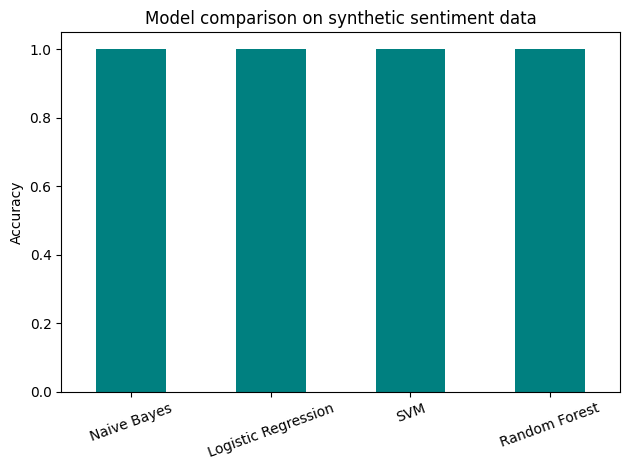

In [39]:
results_df = pd.Series(results, name="accuracy").sort_values(ascending=False)
results_df.plot(kind="bar", color="teal", title="Model comparison on synthetic sentiment data")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [40]:
# Try it on a brand-new sentence
new_reviews = ["This backpack is absolutely amazing and arrived incredibly fast!",
               "Terrible speaker, it stopped working remarkably quickly."]
new_X = vectorizer.transform(new_reviews)

best_model_name = results_df.index[0]
best_model = models[best_model_name]
print(f"Using best model: {best_model_name}")
for text, pred in zip(new_reviews, best_model.predict(new_X)):
    print(f"[{pred}] {text}")


Using best model: Naive Bayes
[positive] This backpack is absolutely amazing and arrived incredibly fast!
[negative] Terrible speaker, it stopped working remarkably quickly.


## 7. Deep Learning Techniques for NLP

We move from bag-of-words features to **sequence models** that respect word order:
ANN (baseline) → RNN → LSTM → GRU. We reuse the same synthetic sentiment dataset from Section 6.


In [49]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Flatten, SimpleRNN, LSTM, GRU, Dropout

tf.random.set_seed(42)

# Turn text into padded integer sequences
tk = Tokenizer(num_words=1000, oov_token="<OOV>")
tk.fit_on_texts(X_train_text)

train_seq = pad_sequences(tk.texts_to_sequences(X_train_text), maxlen=20, padding="post")
test_seq = pad_sequences(tk.texts_to_sequences(X_test_text), maxlen=20, padding="post")

y_train_bin = (y_train == "positive").astype(int).values
y_test_bin = (y_test == "positive").astype(int).values

vocab_size = min(1000, len(tk.word_index) + 1)
print("Vocab size used:", vocab_size, " | Sequence shape:", train_seq.shape)


Vocab size used: 73  | Sequence shape: (225, 20)


### 7.1 Simple ANN baseline (Embedding + Flatten + Dense)

In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense

ann_model = Sequential([
    Embedding(vocab_size, 16, input_length=20),
    Flatten(),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid"),
])
ann_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history_ann = ann_model.fit(train_seq, y_train_bin, epochs=10, validation_split=0.2, verbose=0)
print("ANN test accuracy:", ann_model.evaluate(test_seq, y_test_bin, verbose=0)[1])


ANN test accuracy: 1.0


### 7.2 RNN (SimpleRNN)
Processes tokens one at a time, carrying a "hidden state" forward — but struggles with long
sequences due to vanishing gradients.


In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, SimpleRNN

rnn_model = Sequential([
    Embedding(vocab_size, 16, input_length=20),
    SimpleRNN(16),
    Dense(1, activation="sigmoid"),
])
rnn_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history_rnn = rnn_model.fit(train_seq, y_train_bin, epochs=10, validation_split=0.2, verbose=0)
print("RNN test accuracy:", rnn_model.evaluate(test_seq, y_test_bin, verbose=0)[1])


RNN test accuracy: 1.0


### 7.3 LSTM (Long Short-Term Memory)
Adds gates (input/forget/output) that let the network remember important information over long
sequences and forget irrelevant details.


In [52]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, LSTM

lstm_model = Sequential([
    Embedding(vocab_size, 16, input_length=20),
    LSTM(16),
    Dense(1, activation="sigmoid"),
])
lstm_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history_lstm = lstm_model.fit(train_seq, y_train_bin, epochs=10, validation_split=0.2, verbose=0)
print("LSTM test accuracy:", lstm_model.evaluate(test_seq, y_test_bin, verbose=0)[1])


LSTM test accuracy: 1.0


### 7.4 GRU (Gated Recurrent Unit)
A simplified LSTM — fewer gates, fewer parameters, often trains faster with similar accuracy.


In [53]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, GRU

gru_model = Sequential([
    Embedding(vocab_size, 16, input_length=20),
    GRU(16),
    Dense(1, activation="sigmoid"),
])
gru_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history_gru = gru_model.fit(train_seq, y_train_bin, epochs=10, validation_split=0.2, verbose=0)
print("GRU test accuracy:", gru_model.evaluate(test_seq, y_test_bin, verbose=0)[1])


GRU test accuracy: 0.5066666603088379


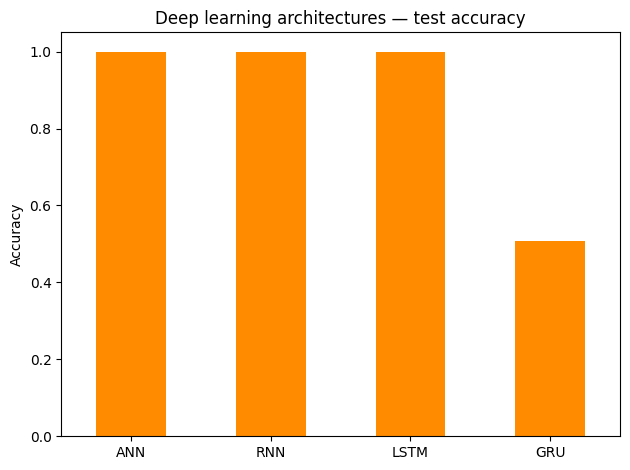

In [54]:
dl_results = {
    "ANN": ann_model.evaluate(test_seq, y_test_bin, verbose=0)[1],
    "RNN": rnn_model.evaluate(test_seq, y_test_bin, verbose=0)[1],
    "LSTM": lstm_model.evaluate(test_seq, y_test_bin, verbose=0)[1],
    "GRU": gru_model.evaluate(test_seq, y_test_bin, verbose=0)[1],
}
pd.Series(dl_results).plot(kind="bar", color="darkorange", title="Deep learning architectures — test accuracy")
plt.ylabel("Accuracy"); plt.ylim(0, 1.05); plt.xticks(rotation=0); plt.tight_layout(); plt.show()


## 8. Sequence-to-Sequence Models & the Transformer Architecture

**Seq2Seq** models (encoder → decoder) map an input sequence to an output sequence of a
*different* length — the basis of machine translation, summarization, and chatbots.
Classic Seq2Seq used two RNNs/LSTMs; modern Seq2Seq uses the **Transformer**, which replaces
recurrence with **self-attention** so all tokens can be processed in parallel and can directly
"look at" any other token, regardless of distance.

Key Transformer ideas:
- **Self-Attention**: each token computes a weighted sum over all other tokens based on relevance.
- **Multi-Head Attention**: several attention "views" run in parallel, each learning different relationships.
- **Positional Encoding**: since there's no recurrence, position information is injected explicitly.
- **Encoder–Decoder stack**: encoder reads the input, decoder generates the output token by token.

Let's implement a minimal (educational, not production) scaled dot-product self-attention from scratch,
so the mechanics are concrete before we use full pretrained Transformers in Section 9.


In [55]:
def softmax(x, axis=-1):
    e_x = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e_x / e_x.sum(axis=axis, keepdims=True)

def scaled_dot_product_attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)
    weights = softmax(scores, axis=-1)
    output = weights @ V
    return output, weights

# Toy example: 4 tokens, embedding dim 8
np.random.seed(0)
tokens = ["The", "cat", "sat", "down"]
X = np.random.randn(4, 8)

# Learned projection matrices (random here, just to show the mechanics)
Wq, Wk, Wv = [np.random.randn(8, 8) * 0.1 for _ in range(3)]
Q, K, V = X @ Wq, X @ Wk, X @ Wv

output, attn_weights = scaled_dot_product_attention(Q, K, V)
pd.DataFrame(attn_weights, index=tokens, columns=tokens).round(2)


,The,cat,sat,down
The,0.24,0.27,0.25,0.24
cat,0.25,0.25,0.25,0.25
sat,0.23,0.25,0.27,0.25
down,0.23,0.27,0.26,0.24


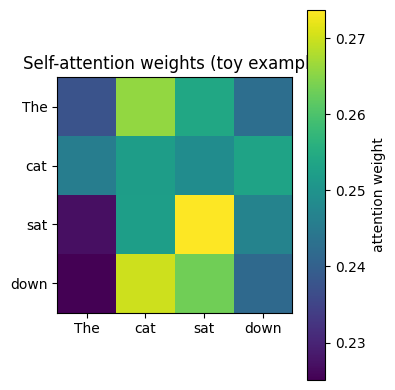

In [56]:
plt.figure(figsize=(4, 4))
plt.imshow(attn_weights, cmap="viridis")
plt.xticks(range(len(tokens)), tokens); plt.yticks(range(len(tokens)), tokens)
plt.title("Self-attention weights (toy example)")
plt.colorbar(label="attention weight")
plt.tight_layout(); plt.show()


## 9. Pretrained Language Models (GPT, T5, and friends) + Transfer Learning

Rather than training a Transformer from scratch (which needs huge data/compute), in practice we
**fine-tune** or directly **use** models already pretrained on massive text corpora:

- **BERT** — encoder-only, great for understanding tasks (classification, NER, QA).
- **GPT** — decoder-only, great for text generation.
- **T5** — encoder-decoder, frames every task as "text-to-text" (translation, summarization, QA all use the same interface).
- **Transformer-XL** — extends the context window using segment-level recurrence, good for long documents.

The easiest way to use any of these is Hugging Face's `pipeline()` API (used throughout Section 10).


In [57]:
from transformers import pipeline

# GPT-2 for text generation
generator = pipeline("text-generation", model="gpt2")
output = generator("Natural Language Processing is", max_length=30, num_return_sequences=1, truncation=True)
print(output[0]["generated_text"])


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 5485.03it/s]
[transformers] Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_outpu

Natural Language Processing is a tool used to understand and improve the English language by translating text into English.

The Language Processing Tool is an application that allows you to analyze and improve the English language and analyze the quality of its English language.

The Language Processing Tool can be used for:

Etymology

The English language is from Latin, meaning "to speak, write, translate".

The English language is derived from Latin, meaning "to speak, write, translate".

The English language is a literary language, or a language that is used throughout history and language, to say, write, or write.

The meaning of English is a simple, but important, one.

Language Processing Tool is designed to help you understand and improve the English language:

What language are you studying?

The English language is divided into three categories:

English

English is the basic form of the English language. It is composed of letters and numbers, and is used to understand and l

In [74]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "t5-small"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)


def run_t5(prompt):
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=128)
    outputs = model.generate(**inputs, max_new_tokens=60)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)


print(run_t5("translate English to French: Natural Language Processing is fascinating."))
print(run_t5("summarize: " + (
    "Natural Language Processing enables computers to understand, interpret, and generate human "
    "language. It powers applications such as chatbots, translation systems, and voice assistants, "
    "and has advanced rapidly with the rise of transformer-based deep learning models."
)))


Loading weights: 100%|██████████| 131/131 [00:00<00:00, 2519.29it/s]


Le traitement des langues naturelles est fascinant.
natural language processing enables computers to understand, interpret, and generate human language. it powers applications such as chatbots, translation systems, and voice assistants.


### 9.1 Transfer Learning via Fine-Tuning (concept + minimal code sketch)

Instead of training from random weights, we start from a pretrained model (e.g. `distilbert-base-uncased`)
and continue training ("fine-tune") on our own small labeled dataset — this needs far less data/compute
than training from scratch, because the model already "knows" language.

```python
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset

# 1) Load a pretrained backbone + attach a classification head
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

# 2) Wrap our synthetic sentiment_df from Section 6 as a HF Dataset
hf_dataset = Dataset.from_pandas(sentiment_df.rename(columns={"label": "labels"}))
hf_dataset = hf_dataset.map(lambda x: {"labels": 1 if x["labels"] == "positive" else 0})
hf_dataset = hf_dataset.map(lambda x: tokenizer(x["review"], truncation=True, padding="max_length"), batched=True)

# 3) Fine-tune with the Trainer API
args = TrainingArguments(output_dir="./out", per_device_train_batch_size=16, num_train_epochs=3)
trainer = Trainer(model=model, args=args, train_dataset=hf_dataset)
trainer.train()
```

*(This full fine-tuning run is left as a workshop exercise — it can take a few minutes even on a GPU,
so we show the pattern rather than executing it live.)*


## 10. Core NLP Tasks

A tour of the tasks NLP is actually used for — each demonstrated with the Hugging Face `pipeline()`
API (or a lighter classic tool where that's more standard), on synthetic or small library data.


### 10.1 Text Classification (recap)
Already covered in depth in Sections 6–7 (Naive Bayes / Logistic Regression / SVM / Random Forest /
RNN / LSTM / GRU on our synthetic sentiment dataset). A modern one-liner using a pretrained model:


In [60]:
zero_shot = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
result = zero_shot(
    "The new phone has an amazing camera and battery life.",
    candidate_labels=["technology", "sports", "food", "finance"],
)
pd.DataFrame({"label": result["labels"], "score": result["scores"]})


Loading weights: 100%|██████████| 515/515 [00:00<00:00, 7054.82it/s]


,label,score
0,technology,0.979053
1,sports,0.011981
2,finance,0.006565
3,food,0.002400


### 10.2 Information Extraction — Named Entity Recognition (NER)
Identifies real-world entities (people, organizations, locations, dates, ...) in text.


In [72]:
ner_text = "Sundar Pichai, the CEO of Google, announced a new partnership with OpenAI in San Francisco on July 8, 2026."

# spaCy NER
doc = nlp(ner_text)
print("--- spaCy NER ---")
for ent in doc.ents:
    print(f"{ent.text:25s} {ent.label_:10s} ({spacy.explain(ent.label_)})")

# Hugging Face NER via token classification pipeline
print("\n--- Transformers NER ---")
ner_pipeline = pipeline("token-classification", model="dslim/bert-base-NER")
for ent in ner_pipeline(ner_text):
    print(f"{ent['word']:25s} {ent['entity_group'] if 'entity_group' in ent else ent['entity']:6s} score={ent['score']:.2f}")


--- spaCy NER ---
Sundar Pichai             PERSON     (People, including fictional)
Google                    ORG        (Companies, agencies, institutions, etc.)
OpenAI                    GPE        (Countries, cities, states)
San Francisco             GPE        (Countries, cities, states)
July 8, 2026              DATE       (Absolute or relative dates or periods)

--- Transformers NER ---


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4145.78it/s]
[transformers] BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Sun                       B-PER  score=1.00
##dar                     I-PER  score=0.99
Pi                        I-PER  score=1.00
##cha                     I-PER  score=1.00
##i                       I-PER  score=1.00
Google                    B-ORG  score=1.00
Open                      B-ORG  score=1.00
##A                       I-ORG  score=1.00
##I                       I-ORG  score=0.99
San                       B-LOC  score=1.00
Francisco                 I-LOC  score=1.00


### 10.3 Word Sense Disambiguation (WSD)
Determining *which meaning* of an ambiguous word is intended, using context. NLTK's Lesk algorithm
compares the sentence against WordNet definitions.


In [63]:
nltk.download('wordnet', quiet=True)
from nltk.wsd import lesk

sentence1 = word_tokenize("I went to the bank to deposit some cash.")
sentence2 = word_tokenize("We sat on the bank of the river and watched the sunset.")

for sent in (sentence1, sentence2):
    sense = lesk(sent, "bank")
    print(" ".join(sent))
    print(" ->", sense, ":", sense.definition() if sense else "no sense found", "\n")


I went to the bank to deposit some cash .
 -> Synset('bank.n.06') : the funds held by a gambling house or the dealer in some gambling games 

We sat on the bank of the river and watched the sunset .
 -> Synset('bank.n.01') : sloping land (especially the slope beside a body of water) 



### 10.4 Sentiment Analysis
Two classic lightweight approaches — **VADER** (rule-based, great for social-media-style text with
emojis/punctuation) and **TextBlob** (polarity + subjectivity) — plus a Transformer-based option.


In [64]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()
social_posts = [
    "I LOVE this new update, it's amazing!! :) 😍",
    "This is the worst service I've ever experienced. Never again.",
    "It's an okay product, nothing special but does the job.",
]

print("--- VADER ---")
for post in social_posts:
    scores = sia.polarity_scores(post)
    print(f"{scores['compound']:+.2f} | {post}")

print("\n--- TextBlob ---")
for post in social_posts:
    tb = TextBlob(post)
    print(f"polarity={tb.sentiment.polarity:+.2f} subjectivity={tb.sentiment.subjectivity:.2f} | {post}")

print("\n--- Transformers (DistilBERT fine-tuned on SST-2) ---")
sentiment_pipeline = pipeline("sentiment-analysis")
for post in social_posts:
    result = sentiment_pipeline(post)[0]
    print(f"{result['label']:8s} ({result['score']:.2f}) | {post}")


[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


--- VADER ---
+0.92 | I LOVE this new update, it's amazing!! :) 😍
-0.62 | This is the worst service I've ever experienced. Never again.
-0.05 | It's an okay product, nothing special but does the job.

--- TextBlob ---
polarity=+0.52 subjectivity=0.74 | I LOVE this new update, it's amazing!! :) 😍
polarity=-0.10 subjectivity=0.95 | This is the worst service I've ever experienced. Never again.
polarity=+0.43 subjectivity=0.54 | It's an okay product, nothing special but does the job.

--- Transformers (DistilBERT fine-tuned on SST-2) ---


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 5777.43it/s]


POSITIVE (1.00) | I LOVE this new update, it's amazing!! :) 😍
NEGATIVE (1.00) | This is the worst service I've ever experienced. Never again.
POSITIVE (1.00) | It's an okay product, nothing special but does the job.


### 10.5 Machine Translation

In [1]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "Helsinki-NLP/opus-mt-en-fr"
translator_tokenizer = AutoTokenizer.from_pretrained(model_name)
translator_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)


def translate_text(text):
    inputs = translator_tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
    outputs = translator_model.generate(**inputs, max_new_tokens=128)
    return translator_tokenizer.decode(outputs[0], skip_special_tokens=True)


english_sentences = [
    "Natural language processing is transforming how we interact with computers.",
    "The workshop covers tokenization, embeddings, and transformers.",
]
for sent in english_sentences:
    print(sent, "->", translate_text(sent))


c:\Users\siddh\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 258/258 [00:00<00:00, 16197.86it/s]
c:\Users\siddh\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\siddh\.cache\huggingface\hub\models--Helsinki-NLP--opus-mt-en-fr. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Wi

Natural language processing is transforming how we interact with computers. -> Le traitement du langage naturel transforme notre façon d'interagir avec les ordinateurs.
The workshop covers tokenization, embeddings, and transformers. -> L'atelier porte sur la tokenisation, l'intégration et les transformateurs.


### 10.6 Text Summarization
Two approaches: an **extractive** method (Sumy's LexRank — selects existing sentences) and an
**abstractive** method (BART/T5 — generates new sentences).


In [2]:
from transformers import pipeline

long_text = (
    "Natural Language Processing (NLP) is a field of artificial intelligence that focuses on the "
    "interaction between computers and human language. It combines computational linguistics with "
    "statistical, machine learning, and deep learning models. Modern NLP systems can perform tasks "
    "such as translation, summarization, sentiment analysis, and question answering. The rise of "
    "transformer architectures, such as BERT and GPT, has significantly improved the accuracy and "
    "fluency of these systems. Today, NLP powers virtual assistants, search engines, and customer "
    "service chatbots used by billions of people every day."
)

# --- Extractive: Sumy LexRank ---
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer as SumyTokenizer
from sumy.summarizers.lex_rank import LexRankSummarizer

parser = PlaintextParser.from_string(long_text, SumyTokenizer("english"))
lexrank_summarizer = LexRankSummarizer()
print("--- Extractive summary (LexRank) ---")
for sentence in lexrank_summarizer(parser.document, 2):
    print("-", sentence)

# --- Abstractive: Hugging Face summarization via text generation ---
print("\n--- Abstractive summary (fallback) ---")
text_gen = pipeline("text-generation", model="gpt2")
prompt = f"Summarize this text in one sentence: {long_text}"
print(text_gen(prompt, max_length=70, num_return_sequences=1, truncation=True)[0]["generated_text"])


c:\Users\siddh\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(


--- Extractive summary (LexRank) ---
- Natural Language Processing (NLP) is a field of artificial intelligence that focuses on the interaction between computers and human language.
- It combines computational linguistics with statistical, machine learning, and deep learning models.

--- Abstractive summary (fallback) ---


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 10570.39it/s]
[transformers] Passing `generation_config` together with generation-related arguments=({'max_length', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=70) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_outp

Summarize this text in one sentence: Natural Language Processing (NLP) is a field of artificial intelligence that focuses on the interaction between computers and human language. It combines computational linguistics with statistical, machine learning, and deep learning models. Modern NLP systems can perform tasks such as translation, summarization, sentiment analysis, and question answering. The rise of transformer architectures, such as BERT and GPT, has significantly improved the accuracy and fluency of these systems. Today, NLP powers virtual assistants, search engines, and customer service chatbots used by billions of people every day.

The NLP field is a field that combines the computational linguistics of machine learning and natural language processing. They combine machine learning and natural language processing to generate abstract sentences. NLP systems can perform various tasks such as translation, summarization, sentiment analysis, and question answering.

The NLP world i

### 10.7 Text Generation

In [69]:
print("--- LSTM-style generation (conceptual, char/word RNN) ---")
print("We already trained an LSTM classifier in Section 7; a *generative* LSTM uses the same "
      "architecture but predicts the NEXT word/character instead of a sentiment label.")

print("\n--- GPT-2 generation ---")
generator = pipeline("text-generation", model="gpt2")
prompt = "In this NLP workshop, participants will learn how to"
outputs = generator(prompt, max_length=40, num_return_sequences=2, truncation=True)
for i, out in enumerate(outputs, 1):
    print(f"{i}. {out['generated_text']}")


--- LSTM-style generation (conceptual, char/word RNN) ---
We already trained an LSTM classifier in Section 7; a *generative* LSTM uses the same architecture but predicts the NEXT word/character instead of a sentiment label.

--- GPT-2 generation ---


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 7049.33it/s]
[transformers] Both `max_new_tokens` (=256) and `max_length`(=40) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


1. In this NLP workshop, participants will learn how to use the NLP to help people find meaning in their lives.

NLP workshops are held daily between 6 – 9 pm in the United States, and they offer an opportunity for people to learn from your experience and share their experience.

This workshop is designed to help people get what they need to have a better life.

Want to learn more about the NLP?

Find more information on the NLP below.
2. In this NLP workshop, participants will learn how to build a powerful NLP, learn how to use it, and create a powerful NLP that you can use in your own projects. Each workshop will feature a unique set of NLP topics, and a series of workshops, workshops, workshops, workshops, workshops, workshops, workshops, workshops, workshops, workshops, workshops, workshops, workshops, workshops, workshops, workshops, workshops, workshops, workshops, workshops, workshops, workshops, workshops, workshops, workshops, workshops, workshops, workshops, workshops, worksh

### 10.8 Question Answering
**Retrieval/extractive QA**: given a context passage, extract the exact answer span (BERT-style).


In [14]:
from transformers import pipeline

generator = pipeline(
    "text-generation",
    model="gpt2"
)

context = (
    "The Transformer architecture was introduced in the 2017 paper 'Attention Is All You Need' "
    "by researchers at Google. It relies entirely on self-attention mechanisms, removing the need "
    "for recurrence found in RNNs and LSTMs. This design allows much greater parallelization during "
    "training and has become the foundation for models like BERT, GPT, and T5."
)

questions = [
    "Who introduced the Transformer architecture?",
    "What mechanism does the Transformer rely on?",
    "What year was the Transformer introduced?",
]

for q in questions:
    prompt = f"""Answer the question using ONLY the context.

Context:
{context}

Question:
{q}

Answer:"""

    result = generator(
        prompt,
        max_new_tokens=40,
        do_sample=False
    )[0]["generated_text"]

    answer = result.split("Answer:")[-1].strip()
    print(f"Q: {q}")
    print(f"A: {answer}\n")


Loading weights: 100%|██████████| 148/148 [00:00<00:00, 3652.41it/s]
[transformers] Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: Who introduced the Transformer architecture?
A: The Transformer architecture was introduced in the 2017 paper 'Attention Is All You Need' by researchers at Google. It relies entirely on self-attention mechanisms, removing the need for rec



[transformers] Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: What mechanism does the Transformer rely on?
A: The Transformer is a self-contained system that is designed to be self-contained. It is designed to be self-contained in the sense that it is self-contained in the sense

Q: What year was the Transformer introduced?
A: The Transformer was introduced in the 2017 paper 'Attention Is All You Need' by researchers at Google. It relies entirely on self-attention mechanisms, removing the need for recurrence



> **Retrieval-Augmented Generation (RAG)**, briefly: instead of relying only on what a language model
> memorized during training, RAG first *retrieves* relevant documents from an external knowledge base
> (e.g. via embedding similarity search) and then feeds them into the model as extra context before
> generating an answer — combining a search engine with a generative model. Great follow-up topic if
> your workshop has a second session!


## 11. Real-World Applications of NLP

| Application | Examples | Techniques from this notebook |
|---|---|---|
| **Voice Assistants** | Siri, Alexa, Google Assistant | Speech-to-text + intent classification + NLG |
| **Grammar & Writing Tools** | Grammarly, MS Word, Google Docs | POS tagging, parsing, language models |
| **Search Engines** | Google, DuckDuckGo | TF-IDF/BM25, embeddings, NER, ranking models |
| **Chatbots & Customer Support** | Website bots, support agents | Intent classification, NER, QA, generation |
| **Machine Translation** | Google Translate, DeepL | Seq2Seq / Transformer encoder-decoder models |
| **Content Moderation** | Social media platforms | Text classification, toxicity detection |
| **Recommendation & Summarization** | News apps, email digests | Embeddings, extractive/abstractive summarization |


## 12. Wrap-up & Practice Exercises

### Recap
- **Preprocessing** cleans raw text (tokenize → remove stopwords/punctuation → stem/lemmatize → normalize → POS tag → parse).
- **Representation** turns text into numbers: one-hot → BoW → TF-IDF → n-grams → LSA/LDA (topics).
- **Embeddings** capture meaning as dense vectors: Word2Vec/GloVe/fastText (static) vs. BERT (contextual).
- **Modeling** ranges from classic ML (Naive Bayes → Random Forest) to deep sequence models (RNN → LSTM/GRU) to Transformers.
- **Pretrained models + transfer learning** (BERT/GPT/T5) let us solve real tasks — classification, NER, sentiment, translation, summarization, generation, QA — with a couple of lines of code.

### Exercises for participants
1. Swap the synthetic sentiment dataset in Section 6 for the real `sklearn.datasets.fetch_20newsgroups` corpus (2 categories) and re-run all four ML models.
2. Change the LDA/LSA topic count in Section 4 and see how the discovered topics change — do they still match our 4 synthetic categories?
3. Extend the `templates`/`topic_vocab` dictionaries in Section 4 with a 5th topic of your choice and re-generate the corpus.
4. Fine-tune `distilbert-base-uncased` (Section 9 code sketch) on the synthetic sentiment data and compare accuracy to the classic ML models from Section 6.
5. Try the zero-shot classifier (Section 10.1) on your own sentence with different candidate labels.
